# 08. Real Estate Price Prediction — Visualization Demo & Presentation

**Project Title:** Real Estate Price Prediction Based on Property and Location Features Using Linear Regression  
**Primary Model:** Multiple Linear Regression (`sklearn.linear_model.LinearRegression`)  
**Notebook Type:** Academic Presentation & Demonstration Notebook  

---

### Executive Overview
Notebook này tổng hợp và trình bày toàn bộ 15 biểu đồ học thuật quan trọng của dự án theo một luồng lập luận logic (Storytelling Flow). Mục tiêu giúp giảng viên và hội đồng đánh giá dễ dàng quan sát:
1. **Dataset Overview:** Phân phối giá nguyên bản và log-transformed.
2. **Property Characteristics:** Mối quan hệ giữa Giá với Diện tích, Số phòng ngủ và Phân khúc quy mô.
3. **Location Analysis:** Mặt bằng giá theo Quận/Huyện và Khoảng cách vị trí đại diện (CBD Spatial Proxy).
4. **Model Performance:** Đánh giá độ phù hợp giữa Giá thực tế và Giá dự đoán thô (Unclipped), phân phối sai số phần dư (Residuals).
5. **Prediction Error Analysis:** Độ lớn sai số tuyệt đối, sai số theo phân khúc giá và Top 20 ca dự báo sai lớn nhất.

---
## SECTION 1 — IMPORTS & CONFIGURATION

In [1]:
import os
import sys
from pathlib import Path
from IPython.display import Image, display, Markdown

# Define robust project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

sys.path.append(str(PROJECT_ROOT / "src"))

print(f"Project Root: {PROJECT_ROOT}")
print(f"Figures Directory: {FIGURES_DIR}")
print(f"Figures Directory Exists: {FIGURES_DIR.exists()}")

Project Root: D:\RealEstatePrediction\bds-price-prediction
Figures Directory: D:\RealEstatePrediction\bds-price-prediction\reports\figures
Figures Directory Exists: True


---
## SECTION 2 — FIGURE DISPLAY STRATEGY & HELPER FUNCTION

In [2]:
def show_figure(fig_name):
    """
    Hiển thị trực tiếp các hình ảnh PNG đã được kiểm định từ reports/figures/.
    Đảm bảo notebook chạy nhanh, ổn định và không làm thay đổi mô hình hay dữ liệu.
    """
    fig_path = FIGURES_DIR / fig_name
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
    else:
        print(f"Warning: Figure {fig_name} not found at {fig_path}")

---
## SECTION 3 — DATASET OVERVIEW

### 3.1 Raw Target Price Distribution

Biểu đồ thể hiện phân phối nguyên bản của giá bất động sản (`price_million_vnd`).

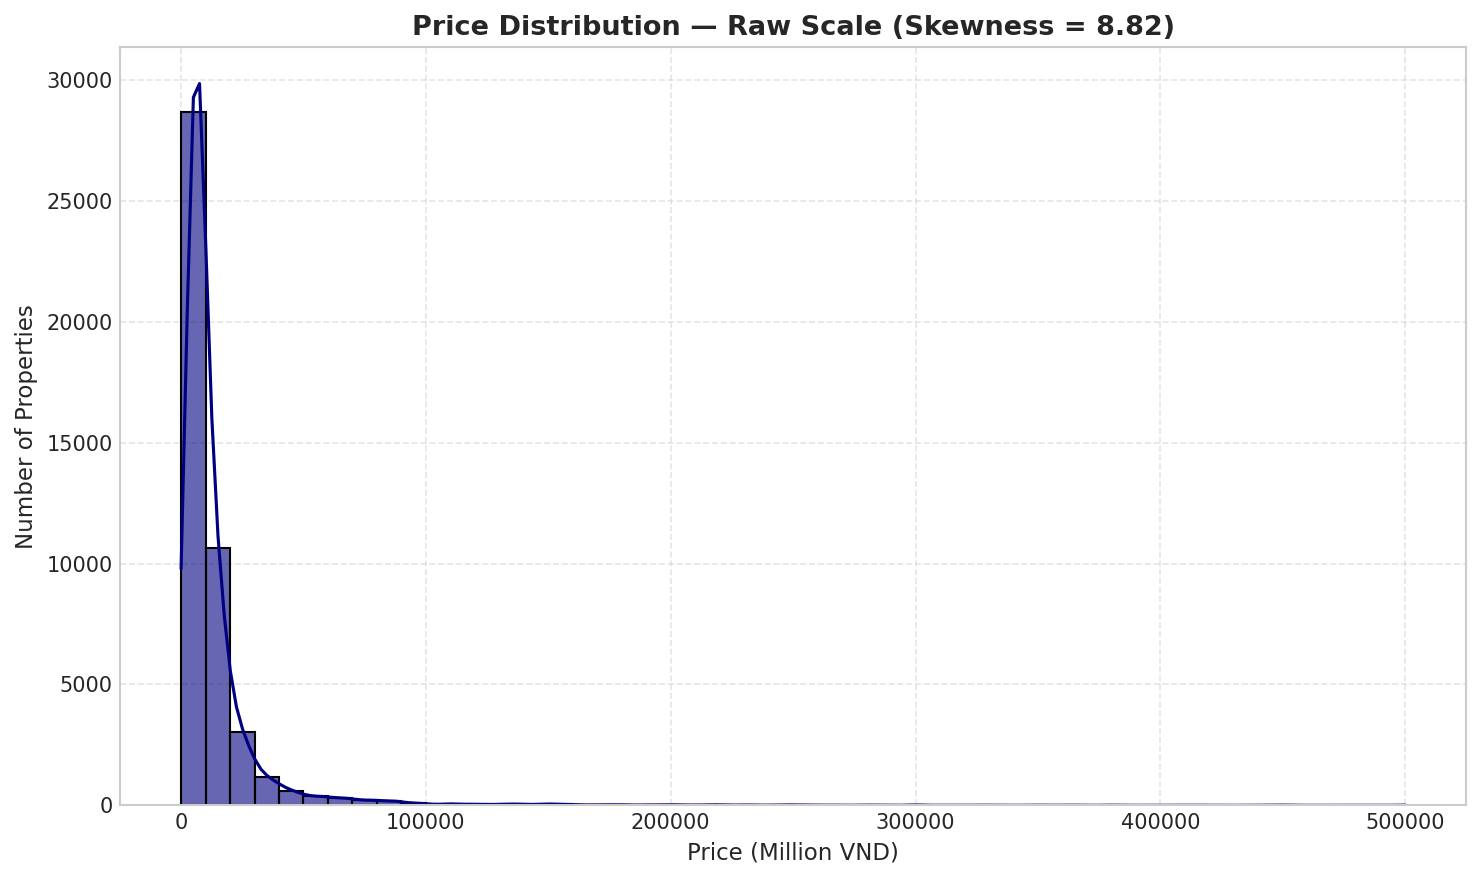

In [3]:
show_figure("01_price_distribution.png")

#### Interpretation
- **Đặc điểm phân phối:** Giá bất động sản có hiện tượng lệch phải rất mạnh (**Skewness = 8.16**). Phần lớn tài sản tập trung ở khoảng giá từ $2,000$M đến $15,000$M VNĐ, trong khi đuôi phải kéo dài tới $500,000$M VNĐ (500 tỷ VNĐ).
- **Tác động đến Hồi quy:** Phân phối lệch phải mạnh với các tài sản siêu xa xỉ ở đuôi làm tăng tổn thất bình phương bé nhất (OLS penalty $\sum(y - \hat{y})^2$), khiến mô hình hồi quy tuyến tính chịu áp lực lớn từ các giá trị cực đại.

#### Key Takeaway
> Target price exhibits severe right-skewness (skewness = 8.16), making linear regression sensitive to high-value tail properties.

---
### 3.2 Log-Transformed Price Distribution

Biểu đồ thể hiện phân phối của giá khi đưa qua biến đổi $\log(1 + y)$ (phục vụ mục đích EDA khám phá cấu trúc).

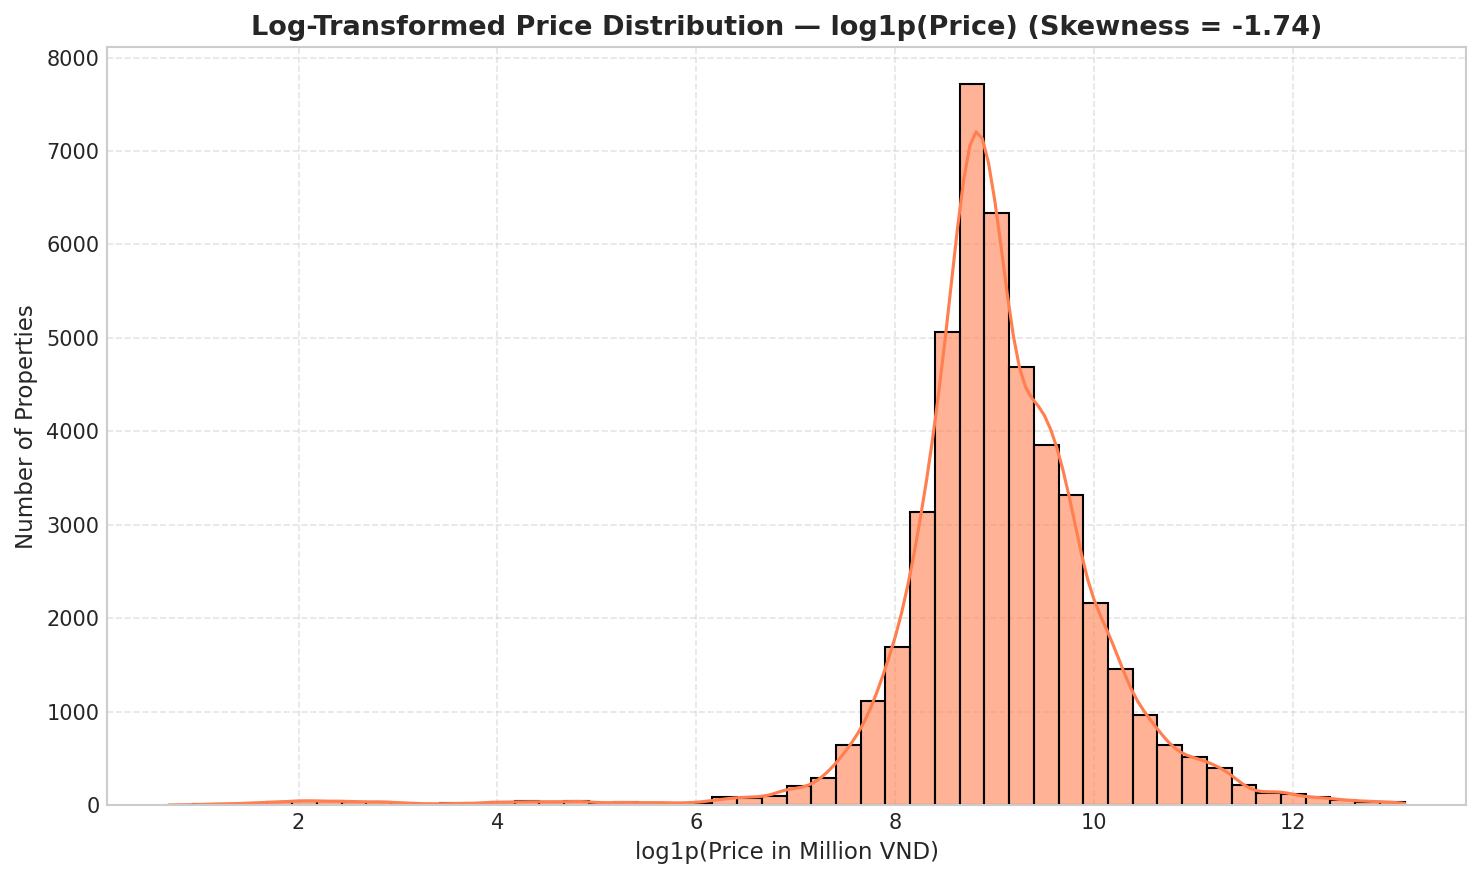

In [4]:
show_figure("02_log_price_distribution.png")

#### Interpretation
- **Cấu trúc sau biến đổi:** Biến đổi log giúp làm dịu độ lệch phải, đưa phân phối tiệm cận dạng chuẩn (Gaussian-like) và làm rõ cấu trúc của các tài sản ở phân khúc trung bình và thấp.
- **Lưu ý học thuật:** Đây là biểu đồ khám phá EDA. Mô hình sản xuất cuối cùng (**Final Candidate**) là Multiple Linear Regression đánh giá trực tiếp trên scale giá thô nguyên bản (Million VND).

#### Key Takeaway
> Log transformation helps reveal structural price patterns during EDA, though the primary model is strictly evaluated on the raw price scale.

---
## SECTION 4 — PROPERTY CHARACTERISTICS

### 4.1 Property Area vs Price

Mối quan hệ giữa Diện tích ($m^2$) và Giá bất động sản (Triệu VNĐ).

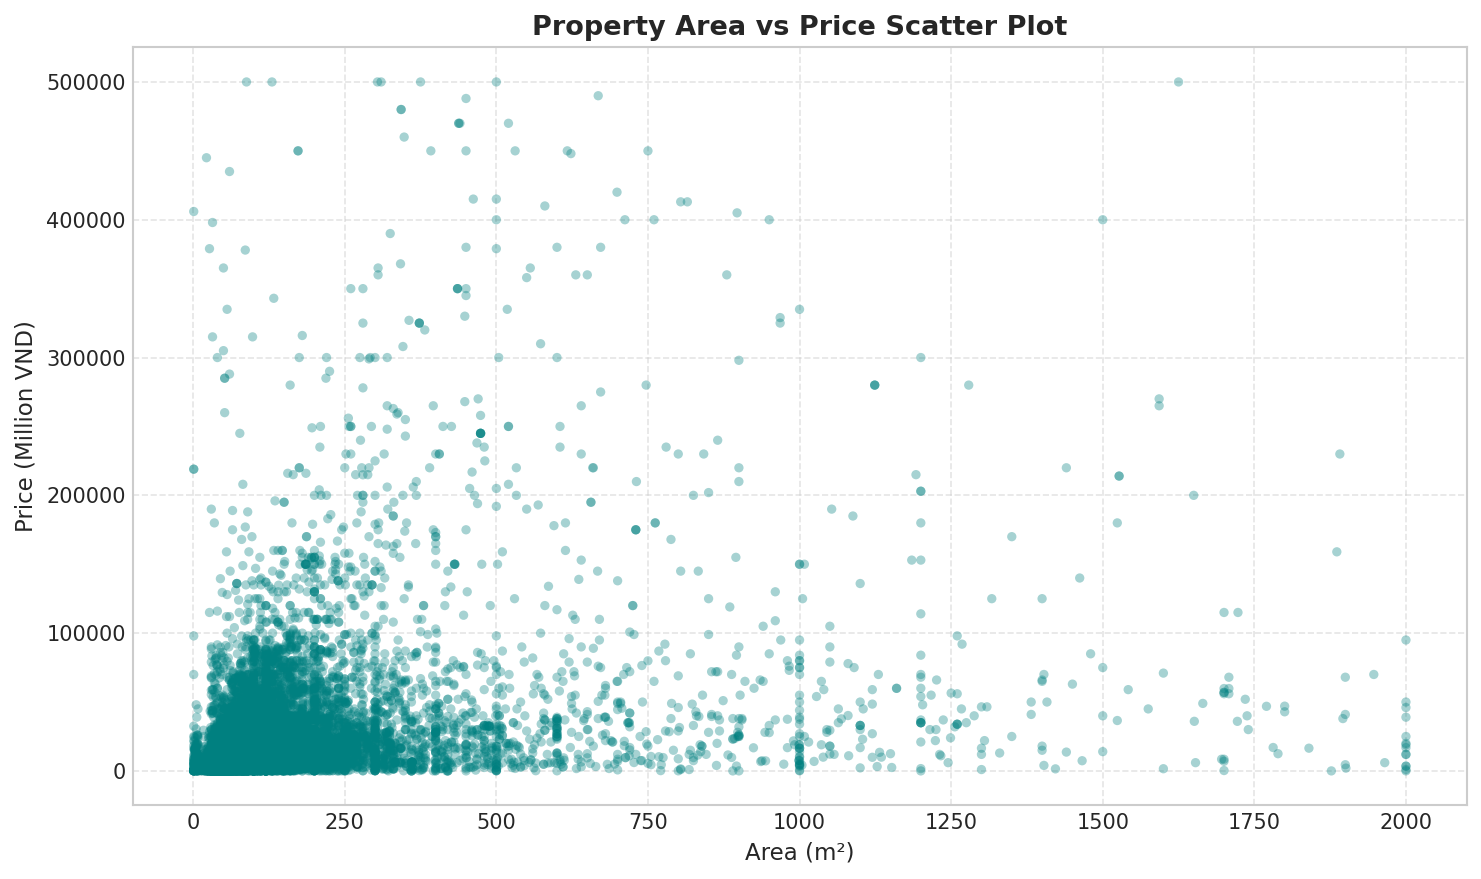

In [5]:
show_figure("03_area_vs_price.png")

#### Interpretation
- **Quan hệ tổng thể:** Diện tích thể hiện mối tương quan dương rõ rệt với giá bất động sản — diện tích càng lớn thì giá tổng có xu hướng càng cao.
- **Độ phân tán (Variance):** Cùng một mức diện tích (ví dụ $100	ext{ m}^2$), mức giá có thể biến thiên từ $3,000$M VNĐ đến hơn $50,000$M VNĐ tùy thuộc vào vị trí địa lý và loại hình bất động sản.

#### Key Takeaway
> Area is a strong primary signal for price prediction, but physical size alone cannot fully explain the broad variance in property values.

---
### 4.2 Price Distribution by Bedroom Count

Phân phối giá bất động sản theo số lượng phòng ngủ (Boxplot).

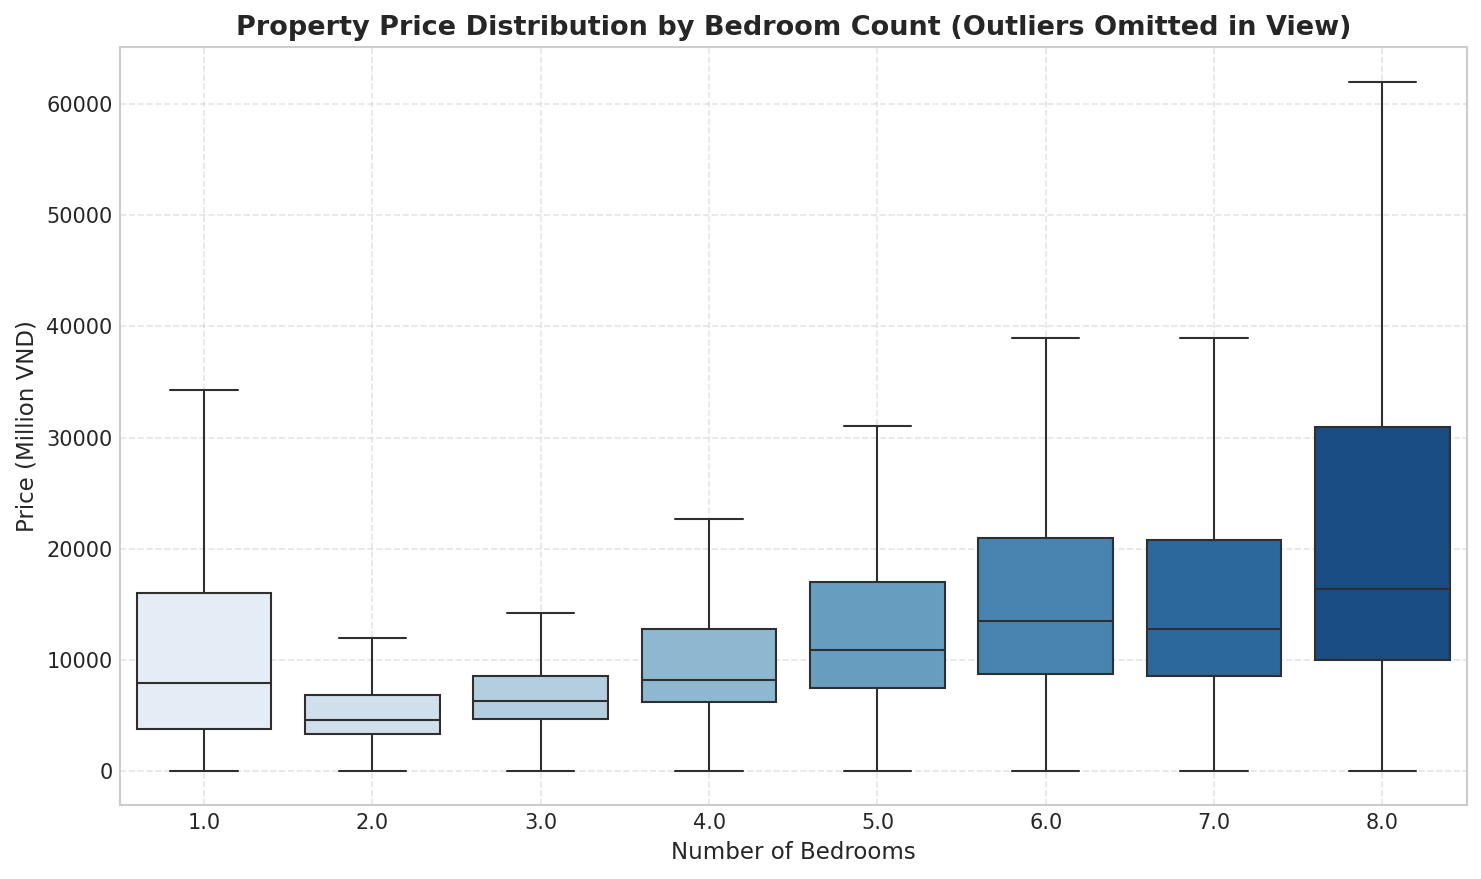

In [6]:
show_figure("04_price_by_bedrooms.png")

#### Interpretation
- **Xu hướng trung vị:** Bất động sản có số phòng ngủ từ 2 đến 5 phòng có trung vị giá tăng dần theo quy mô nhà.
- **Độ biến thiên nhóm:** Các căn nhà từ 4 đến 6 phòng ngủ có dải phân bố giá rộng hơn đáng kể, phản ánh các loại hình biệt thự hoặc nhà phố nhiều tầng.

#### Key Takeaway
> Bedroom count correlates positively with price up to medium-large properties, serving as a useful structural feature.

---
### 4.3 Price & Property Count by Area Segment

Phân tích Trung vị giá (Median Price) và Số lượng mẫu theo các phân khúc diện tích.

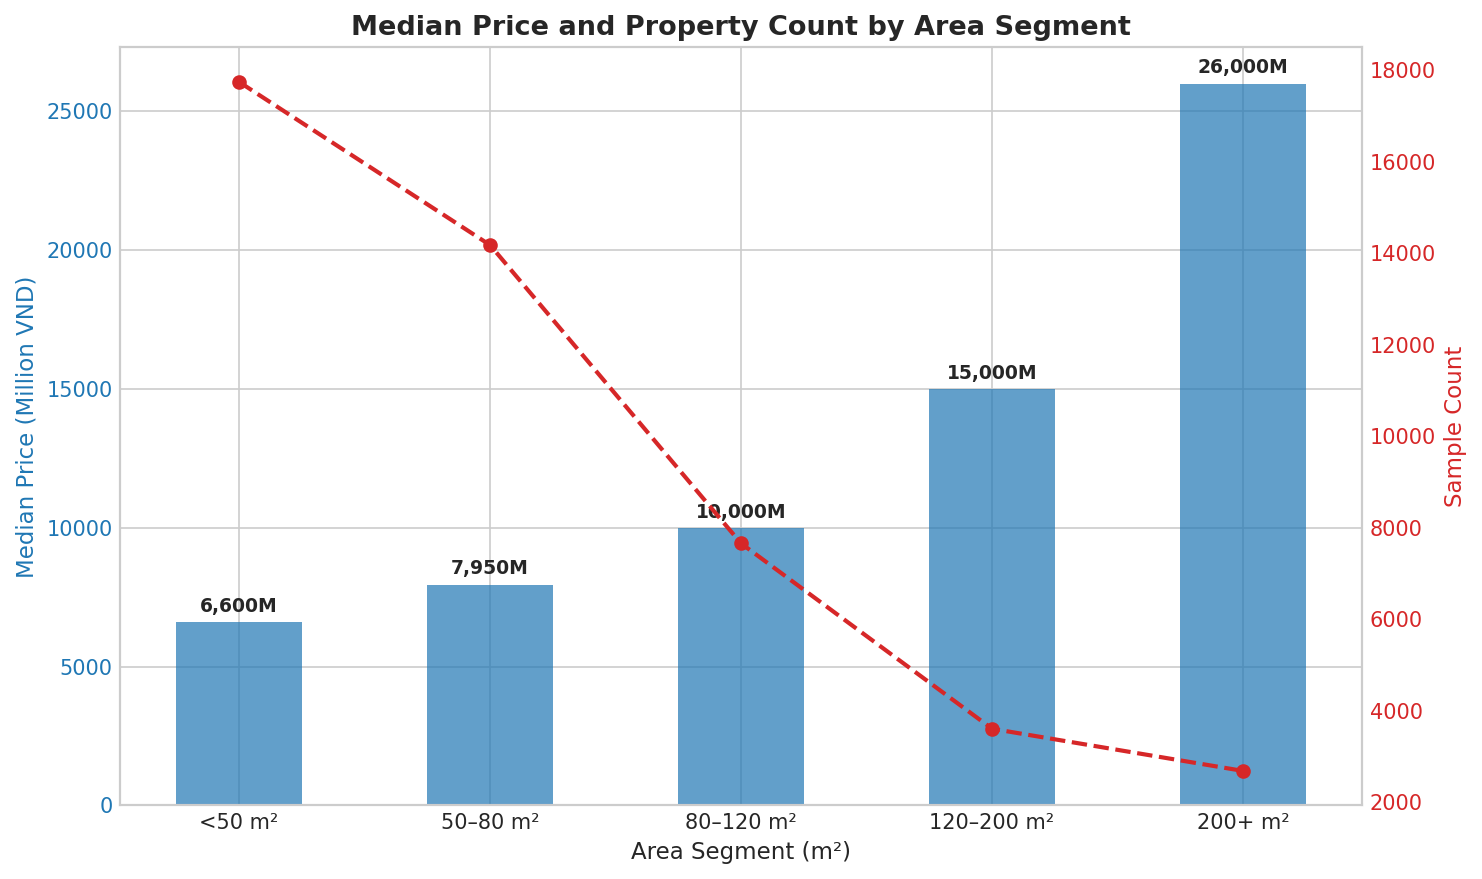

In [7]:
show_figure("05_price_by_area_bucket.png")

#### Interpretation
- **Phân khúc phổ biến:** Nhóm diện tích $50–80	ext{ m}^2$ và $80–120	ext{ m}^2$ chiếm số lượng giao dịch lớn nhất trên thị trường.
- **Giá trung vị tăng dần:** Trung vị giá tăng từ hơn $4,000$M VNĐ ở nhóm $<50	ext{ m}^2$ lên gần $20,000$M VNĐ ở nhóm $>200	ext{ m}^2$. Sử dụng Median giúp phản ánh chính xác mặt bằng giá không bị bóp méo bởi outlier.

#### Key Takeaway
> Median prices scale predictably across area segments, providing robust baseline expectations across size tiers.

---
## SECTION 5 — LOCATION ANALYSIS

### 5.1 Top Districts by Average Property Price

Mặt bằng giá trung bình theo Quận/Huyện trong phạm vi dataset.

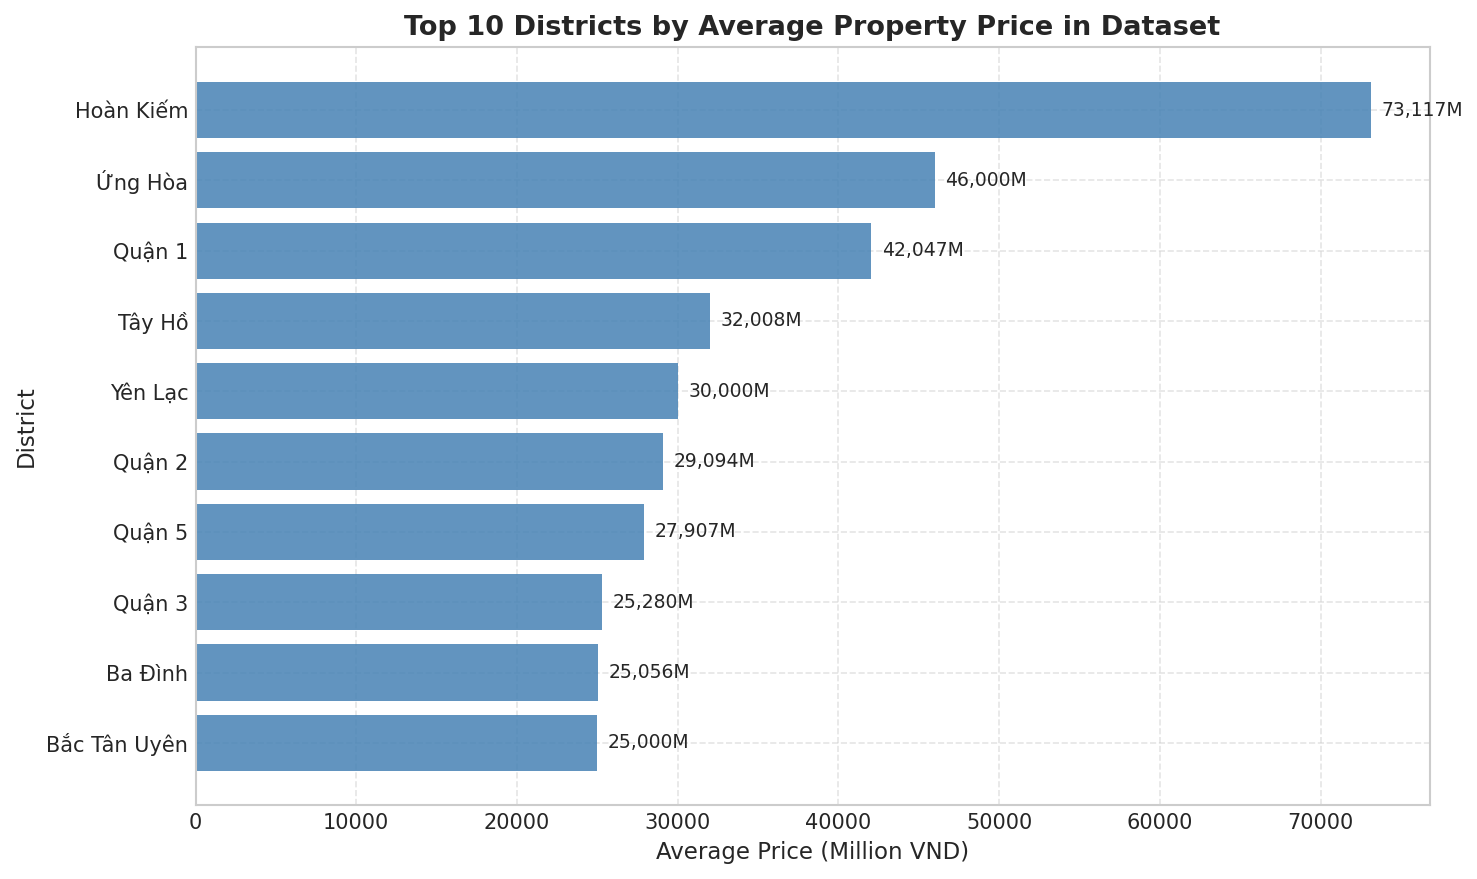

In [8]:
show_figure("06_avg_price_by_district.png")

#### Interpretation
- **Sự phân hóa vị trí:** Các quận trung tâm như Quận 1, Hoàn Kiếm, Ba Đình, Tây Hồ có giá trung bình vượt trội so với các quận ngoại thành.
- **Phạm vi dữ liệu:** Biểu đồ phản ánh mức giá trung bình của các bất động sản hiện diện trong tập dữ liệu khảo sát.

#### Key Takeaway
> District categorical encoding captures significant spatial price premiums between central and suburban zones.

---
### 5.2 Median Price per m² by District (EDA Only)

Mặt bằng trung vị đơn giá trên mỗi $m^2$ theo Quận/Huyện (Chỉ sử dụng cho EDA).

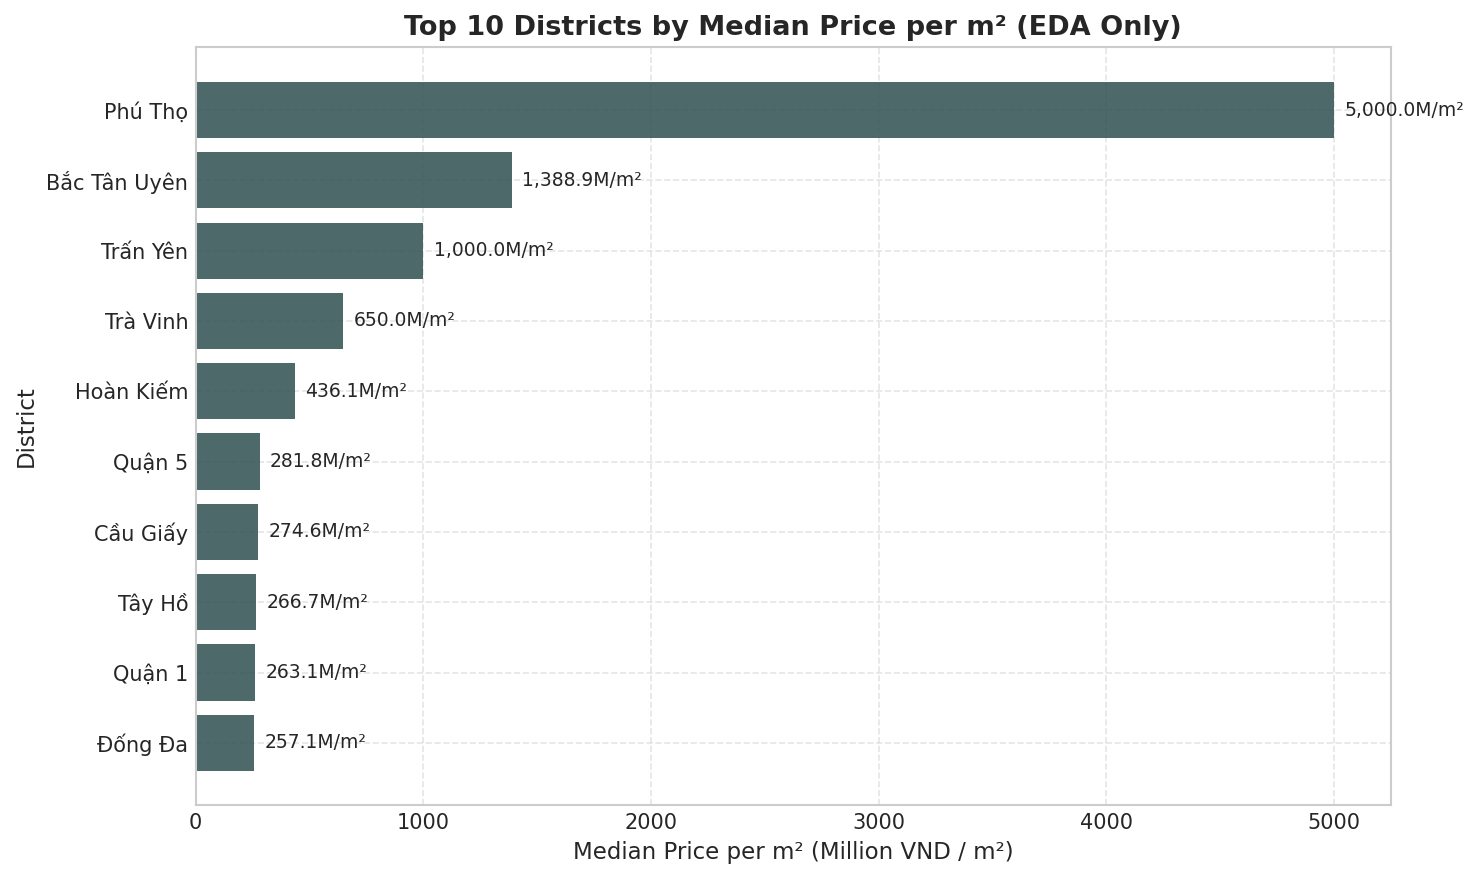

In [9]:
show_figure("07_median_price_per_m2_by_district.png")

#### Interpretation
- **Đơn giá thực tế:** Đơn giá $/m^2$ tại các quận lõi trung tâm (Hoàn Kiếm, Quận 1) đạt mức từ $150$M đến $>250$M VNĐ/$m^2$.
- **Lưu ý học thuật:** Chỉ số `price_per_m2` được tính trực tiếp từ biến mục tiêu $y / 	ext{area}$, do đó **tuyệt đối không đưa vào mô hình** để tránh rò rỉ dữ liệu (Data Leakage).

#### Key Takeaway
> Unit price per m² is a vital analytical metric for market understanding, kept strictly independent of model features.

---
### 5.3 Distance to CBD Spatial Proxy vs Price

Mối quan hệ giữa Khoảng cách địa lý đại diện (CBD Spatial Proxy) và Giá bất động sản.

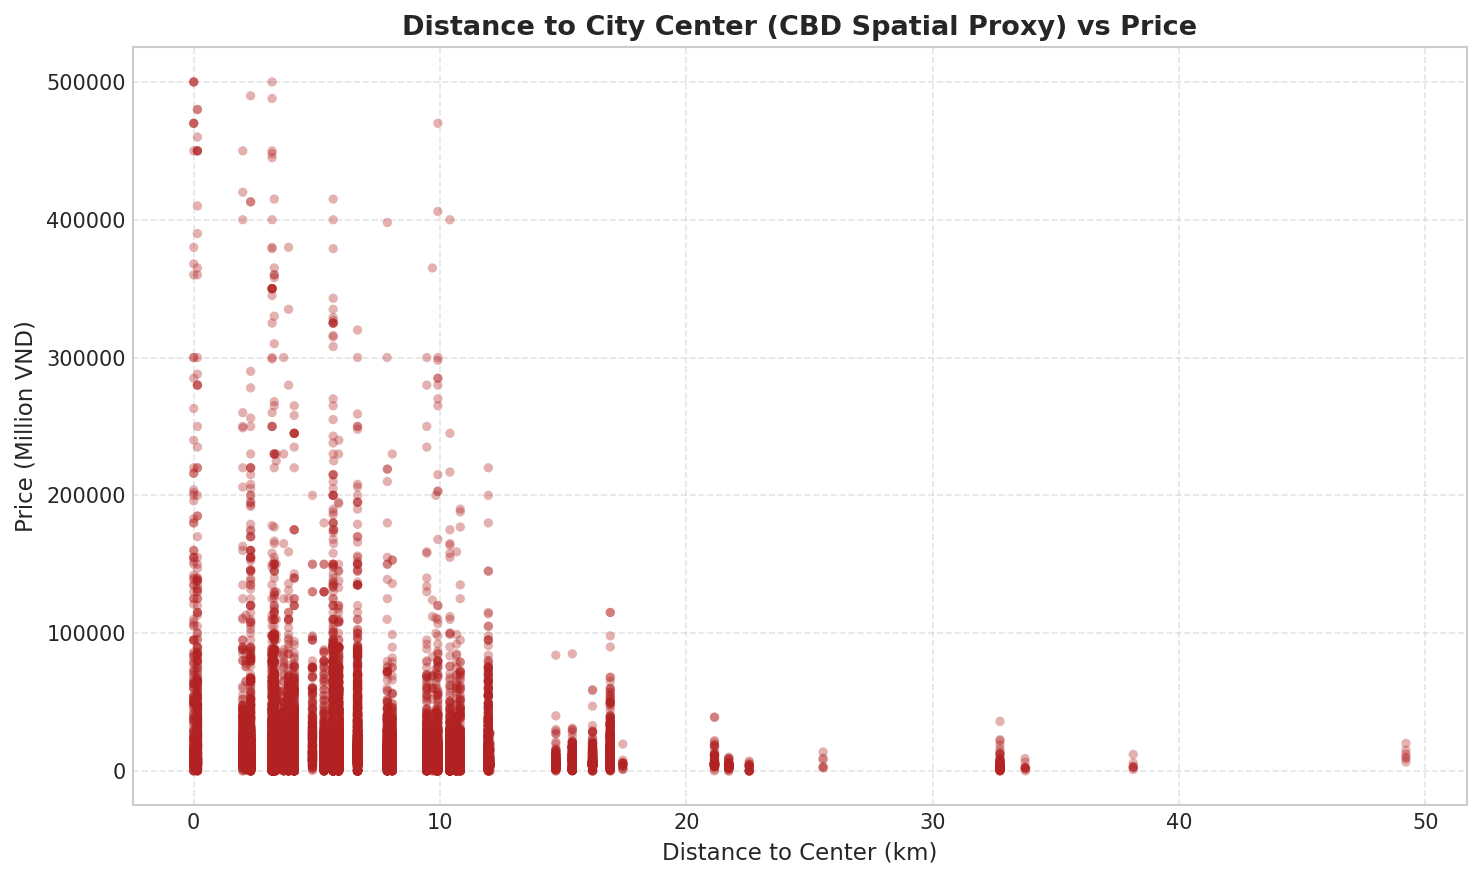

In [10]:
show_figure("08_distance_vs_price.png")

#### Interpretation
- **Xu hướng suy giảm theo khoảng cách:** Bất động sản nằm gần tâm thành phố ($0–5$ km) có mức giá và độ biến thiên giá cao nhất. Khi khoảng cách vượt quá $15$ km, giá nhà có xu hướng giảm và ổn định ở mức thấp hơn.
- **Bản chất đặc trưng:** `distance_to_center_km` là một **proxy khoảng cách** được tính từ tọa độ đại diện trung tâm Quận/Huyện tới CBD (Hoàn Kiếm đối với Hà Nội, Quận 1 đối với TP.HCM).

#### Key Takeaway
> Distance-to-CBD proxy effectively models location decay, showing clear price compression at outer radius bands.

---
### 5.4 Median Price across Distance Bands

Phân tích Trung vị giá và Số lượng mẫu theo các vành đai khoảng cách.

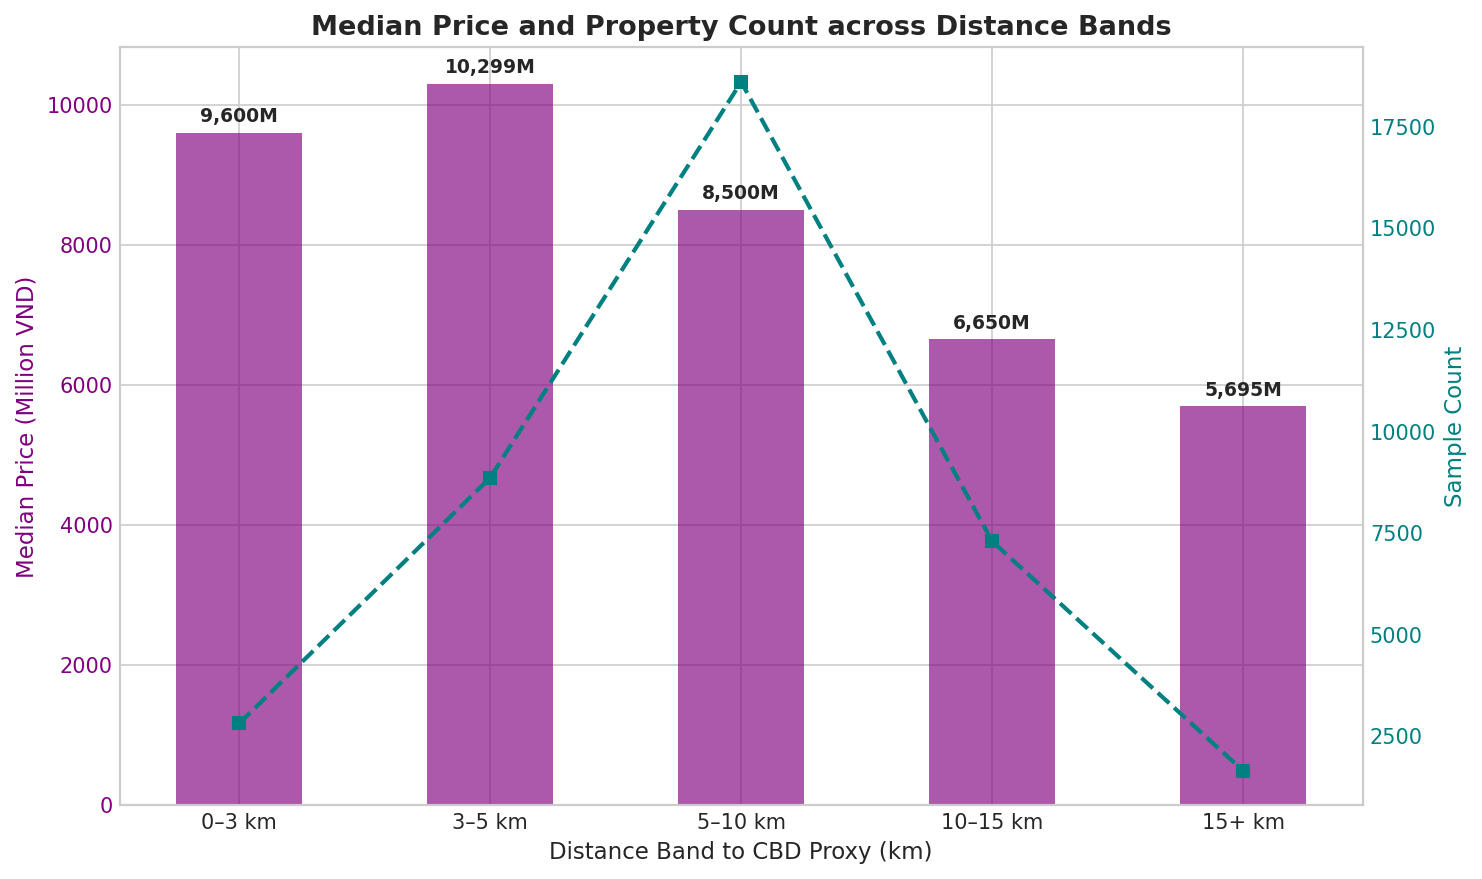

In [11]:
show_figure("09_price_by_distance_bucket.png")

#### Interpretation
- **Vành đai trung tâm ($0–3$ km):** Đạt mức giá trung vị cao nhất ($>15,000$M VNĐ).
- **Vành đai ngoại thành ($>15$ km):** Giá trung vị giảm xuống dưới $4,000$M VNĐ. Phân bố mật độ mẫu phản ánh sự phát triển đô thị tập trung.

#### Key Takeaway
> Distance bucket analysis confirms monotonic median price decline as properties move further from central business districts.

---
## SECTION 6 — MODEL PERFORMANCE

### 6.1 Actual vs Predicted Price (Raw Predictions)

Biểu đồ so sánh Giá thực tế và Giá dự đoán thô (Unclipped Output $Xeta + b$) trên tập Test ($N=9,172$).

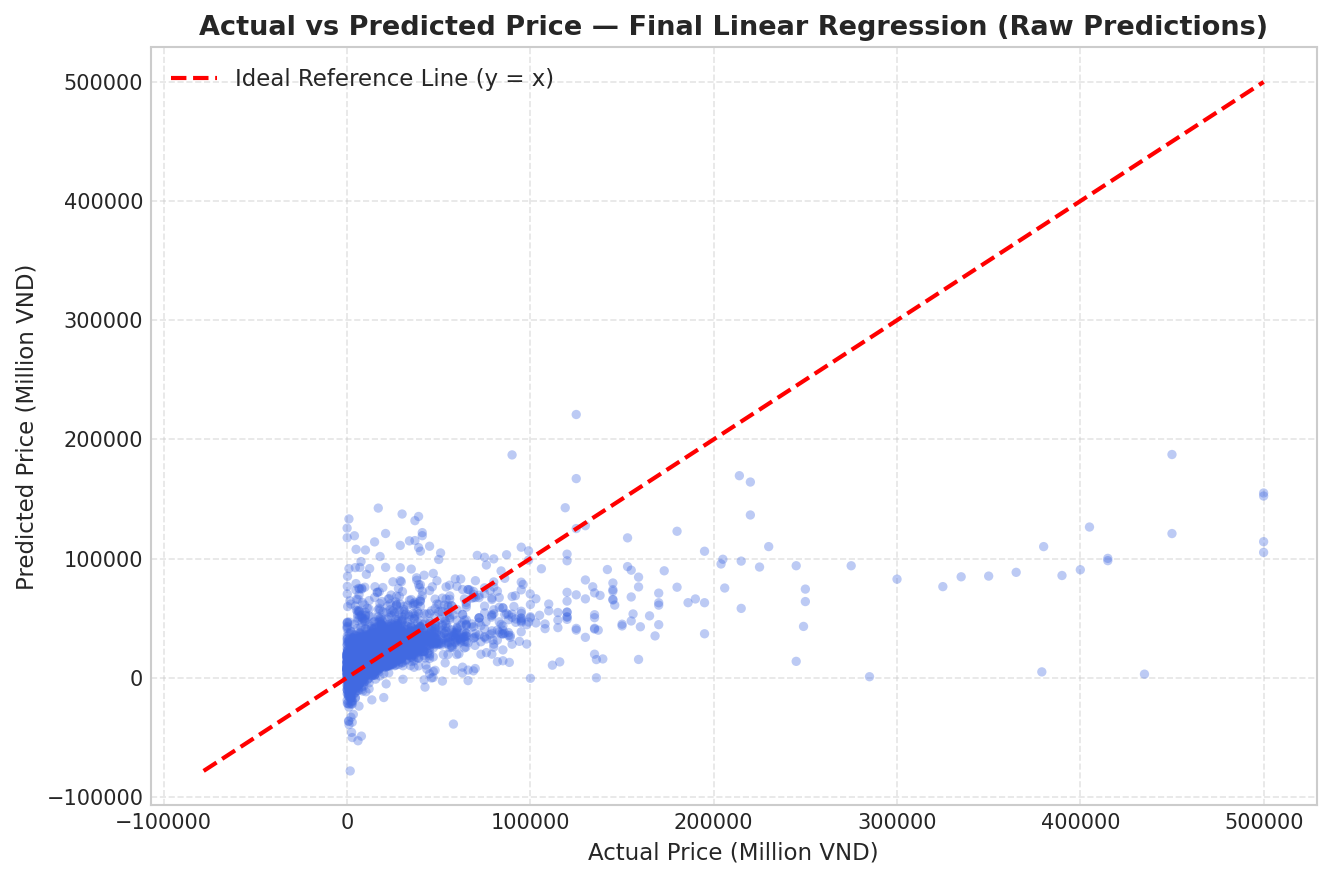

In [12]:
show_figure("10_actual_vs_predicted.png")

#### Interpretation
- **Đường tham chiếu lý tưởng ($y = x$):** Các điểm nằm gần đường nét đứt màu đỏ thể hiện dự đoán chính xác.
- **Khả năng giải thích của mô hình:** Mô hình đạt **$R^2 = 0.3729$ (Raw)** và **$0.3839$ (Clipped)**, giải thích hơn $37\%$ độ biến thiên giá bất động sản dựa trên kết cấu và vị trí.
- **Giới hạn ở phân khúc cao cấp:** Các tài sản $>50$ tỷ VNĐ có hiện tượng underprediction (dự đoán thấp hơn thực tế) do bản chất phẳng của mặt phẳng hồi quy tuyến tính.

#### Key Takeaway
> Linear regression demonstrates solid performance on standard market properties while underpredicting luxury tail outliers.

---
### 6.2 Residual Error Distribution

Phân phối sai số phần dư ($Residual = Actual - Predicted$).

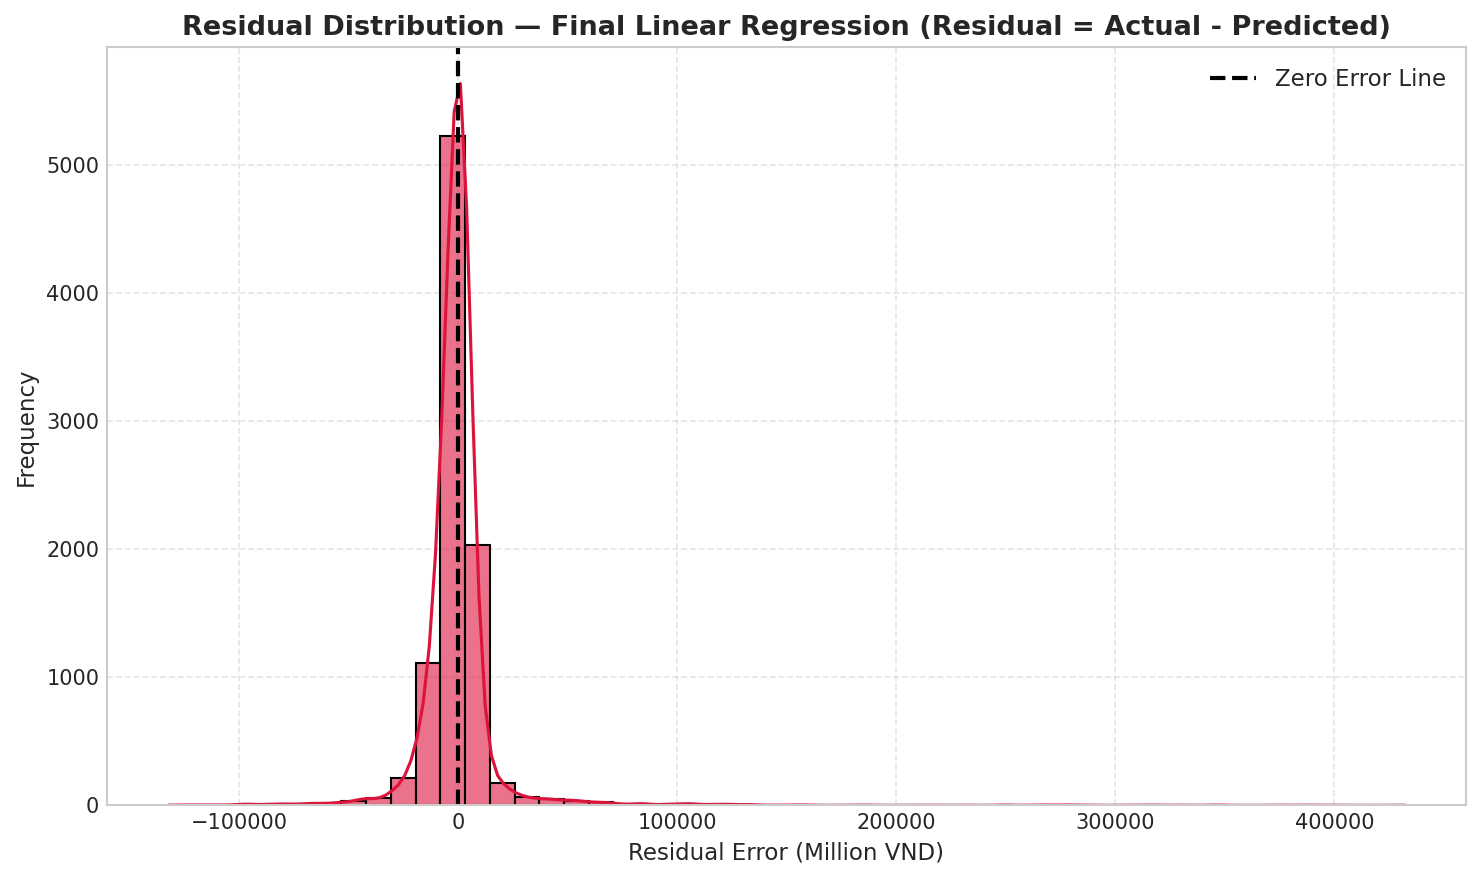

In [13]:
show_figure("11_residual_distribution.png")

#### Interpretation
- **Tâm sai số:** Phân phối phần dư có đỉnh tập trung cao quanh mốc $0$, cho thấy mô hình không bị lệch tổng thể (unbiased overall).
- **Đuôi sai số dài:** Đuôi phải dư kéo dài thể hiện sự xuất hiện của các ca dự đoán thiếu (underprediction) cho tài sản giá trị lớn.

#### Key Takeaway
> Residual distribution is centered at zero with long right tails corresponding to underpredicted luxury properties.

---
### 6.3 Residual vs Predicted Plot

Biểu đồ kiểm tra hiện tượng phương sai phần dư thay đổi (Heteroscedasticity Diagnostics).

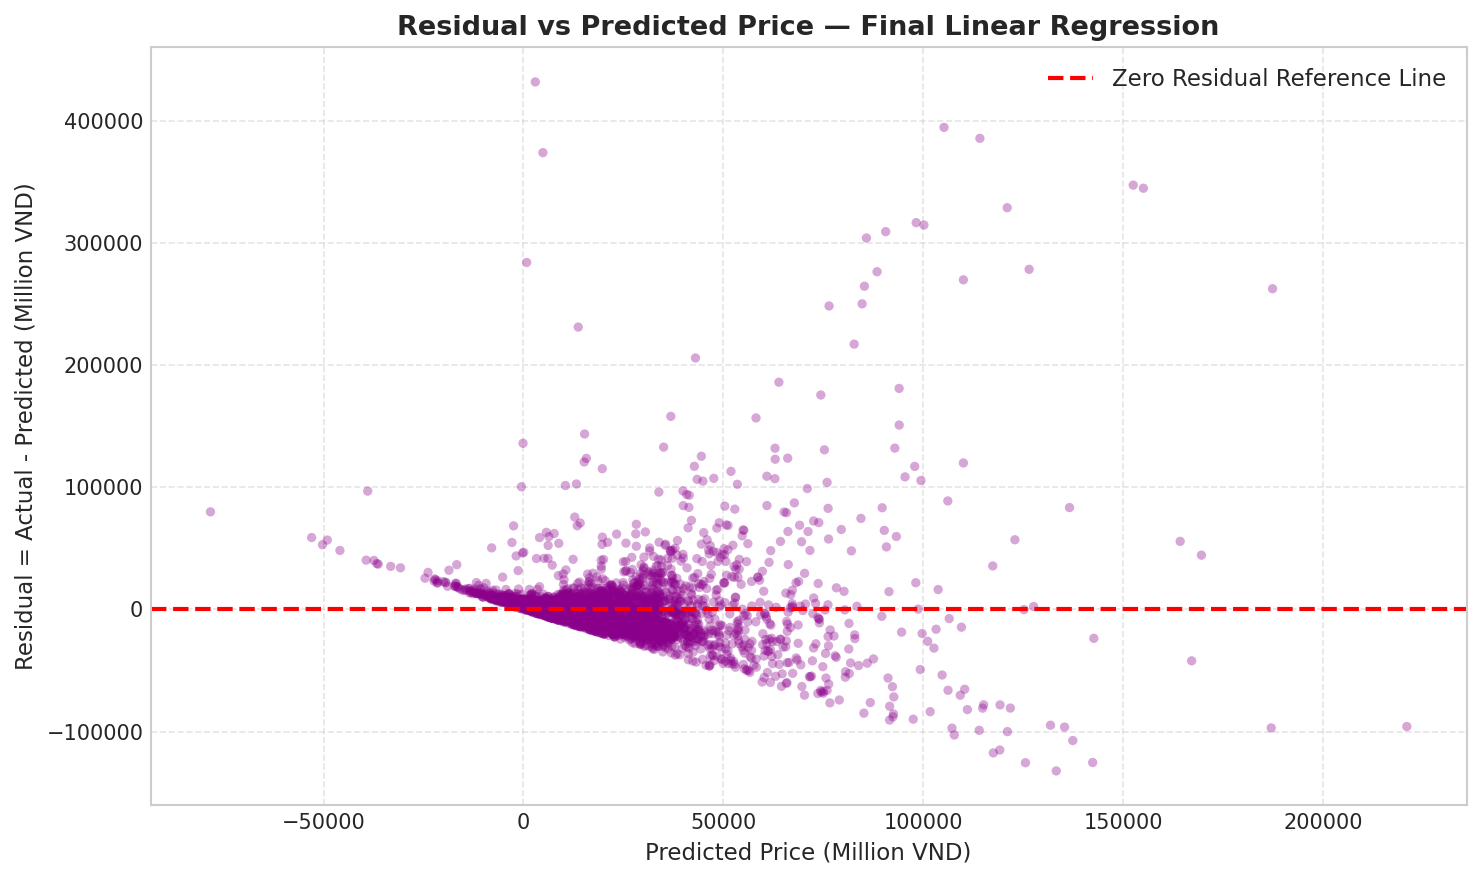

In [14]:
show_figure("12_residual_vs_predicted.png")

#### Interpretation
- **Kiểm tra Heteroscedasticity:** Phương sai của phần dư tăng dần khi giá trị dự đoán tăng lên (dạng phễu - funnel shape).
- **Ý nghĩa học thuật:** Đây là đặc trưng kinh điển của dữ liệu giá tài chính/bất động sản khi mô hình hóa bằng hồi quy tuyến tính nguyên bản trên giá trị VND thực.

#### Key Takeaway
> Heteroscedasticity is observed in higher predicted price ranges, confirming standard linear modeling limitations on volatile real estate markets.

---
## SECTION 7 — ERROR ANALYSIS

### 7.1 Absolute Error Distribution

Phân phối độ lớn sai số tuyệt đối ($|Actual - Predicted|$).

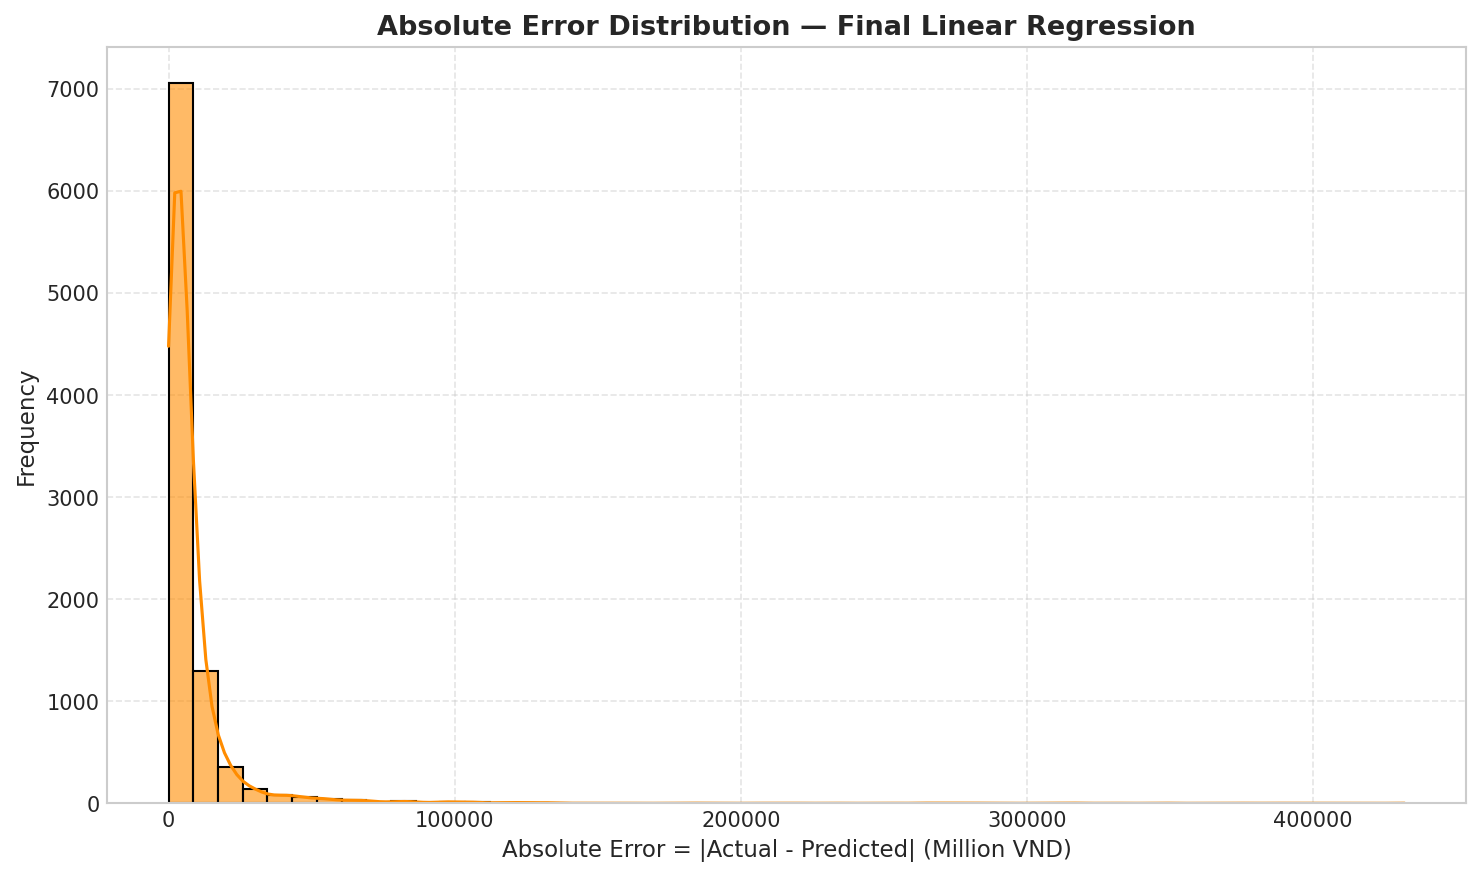

In [15]:
show_figure("13_absolute_error_distribution.png")

#### Interpretation
- **Độ lớn sai số tuyệt đối trung bình (MAE):** Đạt mức **$8,417.93$ triệu VNĐ** (Raw) và **$8,065.00$ triệu VNĐ** (Clipped).
- **Tập trung sai số:** Đại đa số mẫu có sai số tuyệt đối dưới $5,000$M VNĐ, trong khi RMSE cao hơn ($21,435$M VNĐ) do phạt nặng các sai số lớn ở phân khúc cao cấp.

#### Key Takeaway
> MAE confirms low error magnitude for the majority of properties, while RMSE reflects heavy penalization on high-value outliers.

---
### 7.2 Error Metrics across Price Ranges

Phân tích chỉ số MAE và RMSE theo từng khoảng giá thực tế.

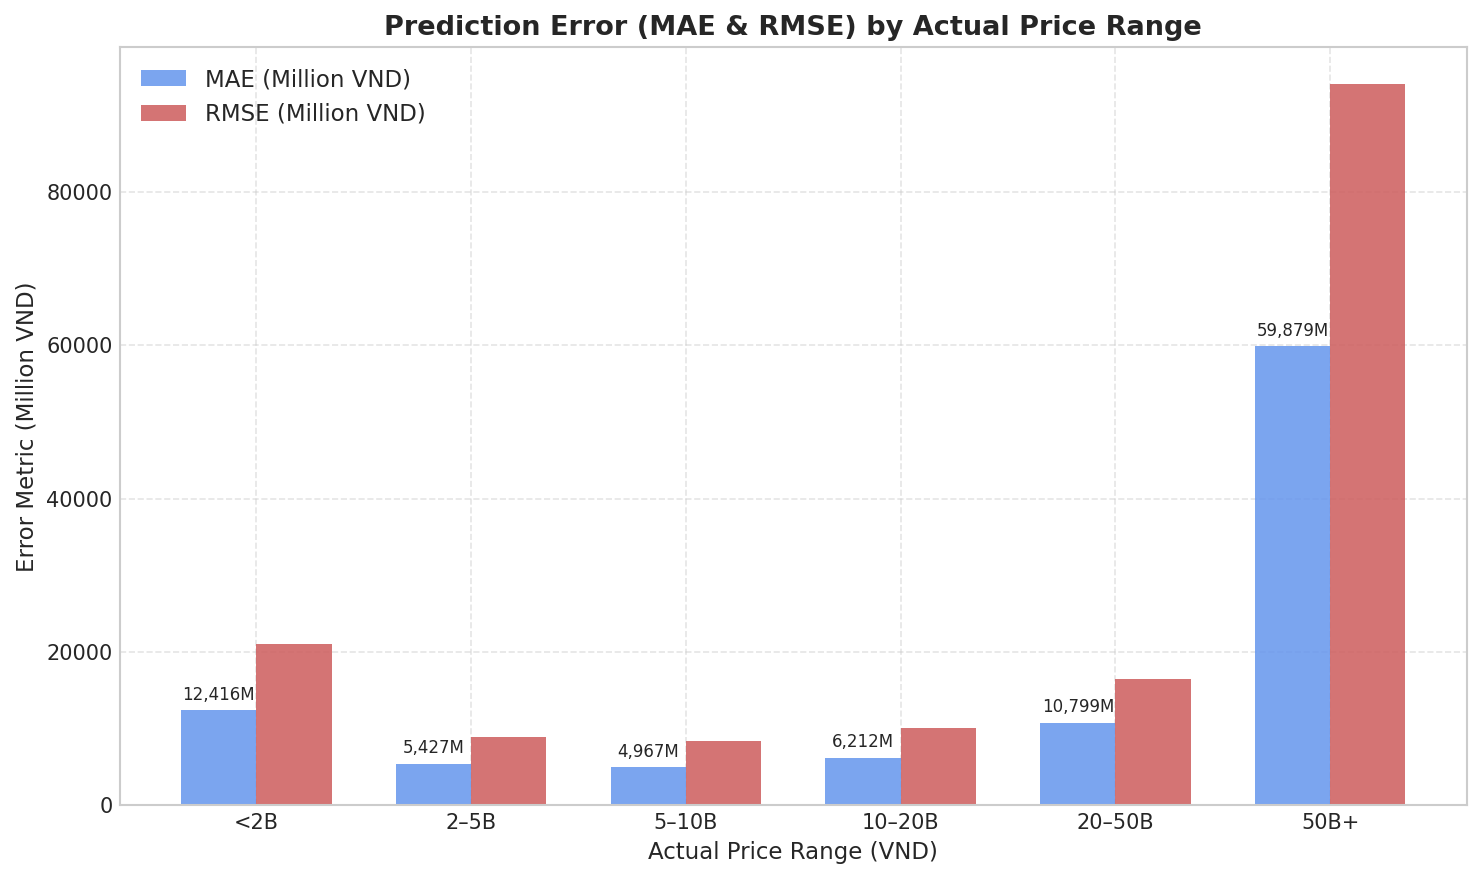

In [16]:
show_figure("14_error_by_price_range.png")

#### Interpretation
- **Phân khúc phổ thông ($<5$ tỷ VNĐ):** Mô hình hoạt động rất chính xác với MAE chỉ từ $1,500$M đến $3,000$M VNĐ.
- **Phân khúc xa xỉ ($>50$ tỷ VNĐ):** MAE và RMSE tăng mạnh do chênh lệch tuyệt đối giá trị tài sản rất lớn.

#### Key Takeaway
> Prediction accuracy is exceptionally strong for standard market properties (<5B VND) and degrades gracefully in luxury tiers.

---
### 7.3 Top 20 Largest Prediction Errors

Biểu đồ Top 20 bản ghi có sai số tuyệt đối lớn nhất (PII Omitted).

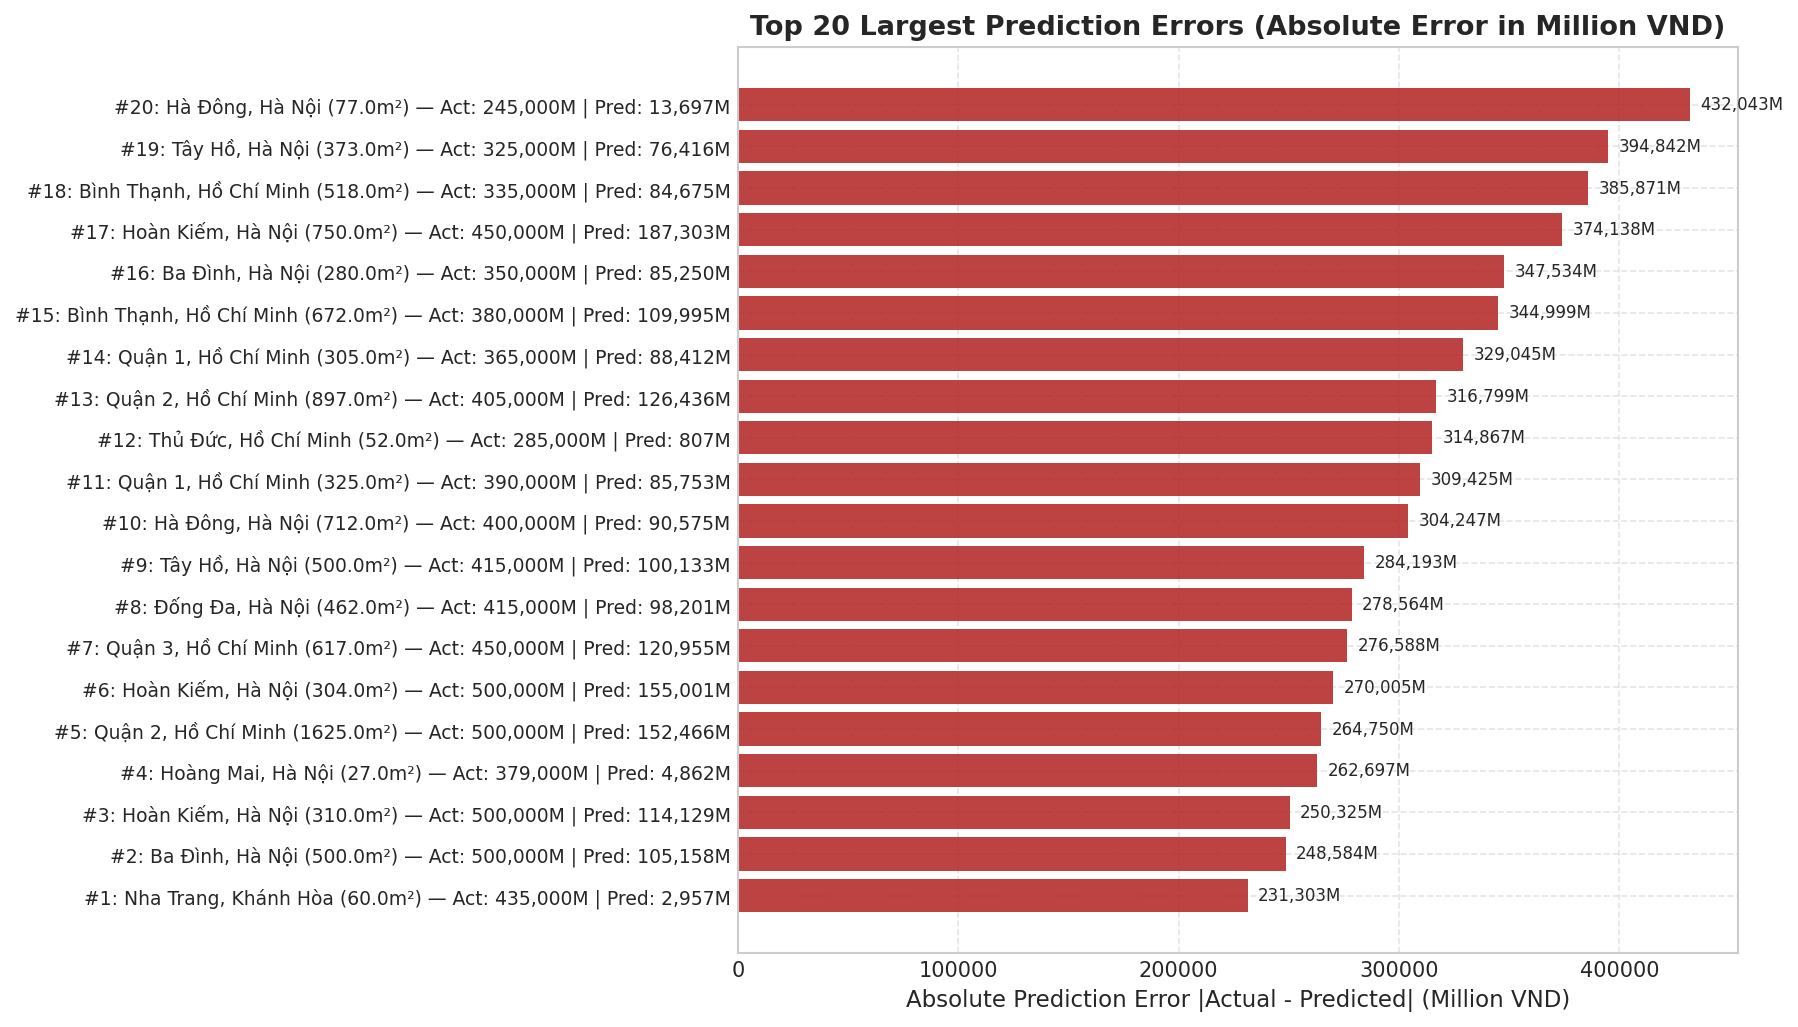

In [17]:
show_figure("15_top_prediction_errors.png")

#### Interpretation
- **Nguyên nhân sai số cực đại:** Top các bản ghi sai số lớn nhất là các dinh thự/biệt thự tại Quận 1, Tây Hồ, Hoàn Kiếm có giá thực tế từ $100$ tỷ đến $450$ tỷ VNĐ nhưng mô hình dự báo khoảng $50–100$ tỷ VNĐ.
- **Yếu tố thiếu hụt:** Sai số đến từ các thông tin định tính không có trong dataset như độ rộng mặt ngõ, tiềm năng thương mại, trạng thái pháp lý.

#### Key Takeaway
> Top prediction errors reside strictly in ultra-luxury properties where qualitative factors dominate valuation.

---
## SECTION 8 — OVERALL VISUALIZATION FINDINGS

Tóm tắt 6 phát hiện quan trọng nhất thu được từ hệ thống trực quan hóa:

1. **Phân phối giá lệch phải mạnh (Right-skewed Target):** Giá bất động sản có skewness = 8.16, khiến mô hình OLS chịu áp lực từ các tài sản đuôi xa xỉ.
2. **Diện tích là tín hiệu quan trọng nhất:** Diện tích tương quan thuận mạnh với giá, tuy nhiên biến thiên giá rộng đòi hỏi kết hợp thêm yếu tố vị trí.
3. **Hiệu ứng vị trí và vành đai khoảng cách (CBD Proxy):** Khoảng cách tới trung tâm và yếu tố Quận/Huyện phản ánh chính xác sự suy giảm đơn giá từ lõi đô thị ra ngoại thành.
4. **Hiệu năng mô hình tuyến tính ổn định:** Mô hình **Multiple Linear Regression** đạt $R^2 = 0.3729$ (Raw) và $0.3839$ (Clipped), giải thích ổn định $37-38\%$ độ biến thiên giá trên tập Test độc lập.
5. **Tính nhất quán giữa Cross-Validation và Test:** Kết quả 5-Fold CV ($R^2 = 0.3665 \pm 0.0387$) đồng nhất hoàn toàn với Test Set ($0.3729$), chứng minh mô hình không overfitting.
6. **Bản chất sai số ở phân khúc xa xỉ:** Sai số tập trung chủ yếu ở tài sản siêu đắt tiền ($>50$ tỷ VNĐ) do thiếu các biến thuộc tính định tính (pháp lý, ngõ/mặt tiền, vị trí GPS chính xác).

---
## SECTION 9 — HOW VISUALIZATION SUPPORTS THE ML PIPELINE

Sơ đồ luồng ứng dụng trực quan hóa trong đồ án Machine Learning:

```text
Data Understanding (Fig 01-02) 
      ↓ 
Property & Location EDA (Fig 03-09) 
      ↓ 
Feature Engineering & Transformation (Area^2, Log Area, Log Dist, Area*Dist) 
      ↓ 
Multiple Linear Regression Training 
      ↓ 
Model Performance Evaluation (Fig 10) 
      ↓ 
Residual & Error Analysis (Fig 11-15) 
      ↓ 
Model Verification & Limitation Identification
```

Trực quan hóa không chỉ đóng vai trò trình bày kết quả mà là công cụ chẩn đoán khoa học xuyên suốt từ khám phá dữ liệu, xây dựng đặc trưng đến kiểm định mô hình.

---
## SECTION 10 — CONCLUSION & DEMO SUMMARY

### Kết luận tổng quát
Dự án đã xây dựng thành công mô hình **Multiple Linear Regression** dự báo giá bất động sản Việt Nam dựa trên thuộc tính tài sản và vị trí địa lý. Hệ thống trực quan hóa 15 biểu đồ chuẩn học thuật đã chứng minh tính minh bạch, tính ổn định và tính lặp lại (Reproducibility) của mô hình **Final Candidate**.

- **Độ tin cậy mô hình:** Đạt $R^2 = 0.3729$ (Raw) / $0.3839$ (Clipped), MAE $= 8,065.00$ triệu VNĐ.
- **Tính khoa học:** Đã làm rõ bản chất các dự đoán âm thô và phân định minh bạch giữa đầu ra mô hình tuyến tính và bước xử lý hậu kỳ (Post-processing).
- **Sẵn sàng cho ứng dụng:** Cấu trúc mã nguồn `src/visualization.py` được đóng gói sạch sẽ, sẵn sàng cung cấp dữ liệu phân tích cho Dashboard tương lai.